## 1. Learning Algorithms
Total Marks:50
Implement a simple learning algorithm (Linear Regression) using Gradient Descent. Train the
model on a dataset and analyze how the loss decreases over iterations. Plot the learning curve.

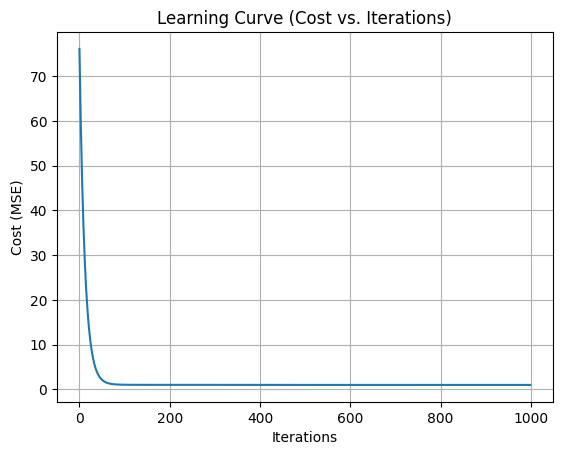

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]

learning_rate = 0.01
n_iterations = 1000
m = len(X_b)

theta = np.random.randn(2, 1)

cost_history = []

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T @ (X_b @ theta - y)
    theta = theta - learning_rate * gradients
    cost = np.mean((X_b @ theta - y)**2)
    cost_history.append(cost)

plt.plot(range(n_iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Learning Curve (Cost vs. Iterations)')
plt.grid(True)
plt.show()

## 2. Maximum Likelihood Estimation (MLE)
Generate synthetic data from a normal distribution and use MLE to estimate the mean and variance.
Compare estimated values with actual parameters.

In [2]:
import numpy as np
import scipy.stats as stats

np.random.seed(42)

# Actual parameters for the normal distribution
actual_mean = 10
actual_std = 2
actual_variance = actual_std**2

# Generate synthetic data from a normal distribution
data = np.random.normal(actual_mean, actual_std, 1000)

# Estimate mean using MLE (sample mean)
estimated_mean = np.mean(data)

# Estimate variance using MLE (sample variance, uncorrected)
# For MLE, the divisor is N, not N-1 (which is for unbiased sample variance)
estimated_variance = np.sum((data - estimated_mean)**2) / len(data)

print(f"Actual Mean: {actual_mean:.2f}")
print(f"Estimated Mean (MLE): {estimated_mean:.2f}\n")

print(f"Actual Variance: {actual_variance:.2f}")
print(f"Estimated Variance (MLE): {estimated_variance:.2f}")

Actual Mean: 10.00
Estimated Mean (MLE): 10.04

Actual Variance: 4.00
Estimated Variance (MLE): 3.83


## 3. Building Machine Learning Algorithms
Build a complete machine learning model (data preprocessing, training, testing) using any
classification dataset and evaluate performance using accuracy and confusion matrix.

Accuracy: 0.91

Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]


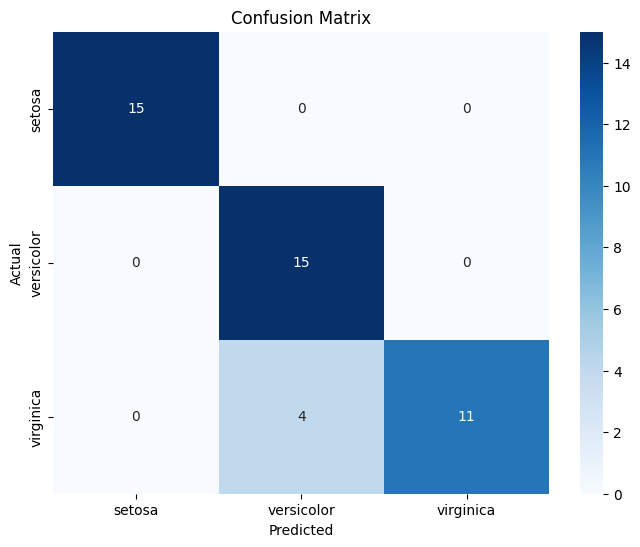

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# 1. Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Data Preprocessing
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Training
# Using K-Nearest Neighbors (KNN) classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 4. Model Testing and Evaluation
y_pred = knn.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 4. Neural Networks
Design a simple neural network with one hidden layer and train it on a small dataset. Analyze how
the network learns non-linear patterns.

Training complete.


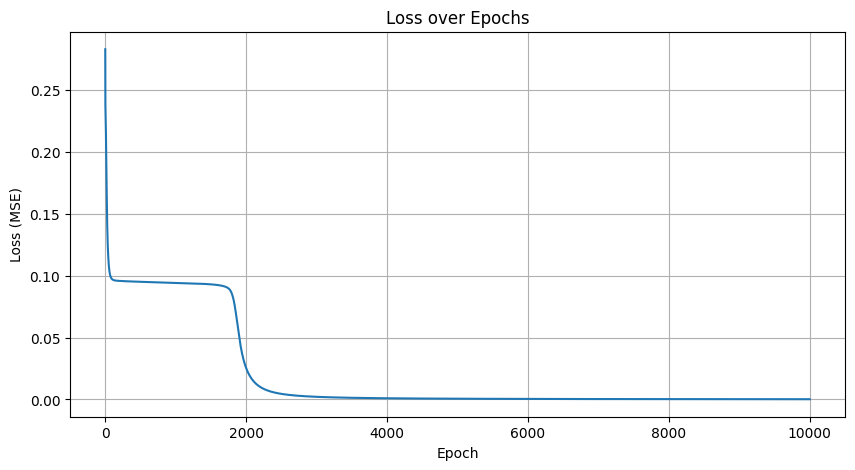

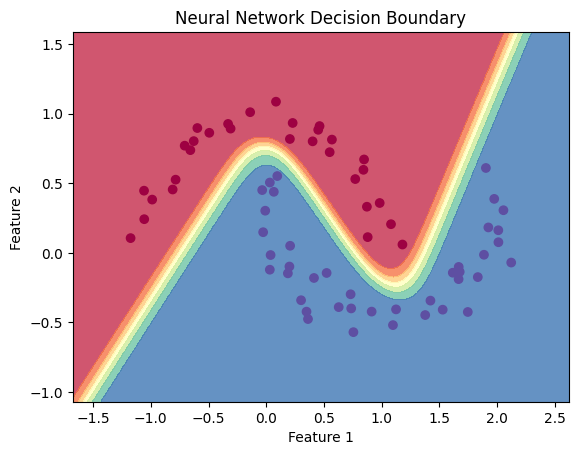

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid function
def sigmoid_derivative(x):
    return x * (1 - x)

# Generate a non-linear dataset (make_moons)
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)
y = y.reshape(-1, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Neural network architecture
input_size = X.shape[1]
hidden_size = 4
output_size = 1

# Initialize weights and biases
np.random.seed(42)
weights_input_hidden = np.random.uniform(size=(input_size, hidden_size))
bias_hidden = np.random.uniform(size=(1, hidden_size))
weights_hidden_output = np.random.uniform(size=(hidden_size, output_size))
bias_output = np.random.uniform(size=(1, output_size))

# Learning parameters
learning_rate = 0.1
epochs = 10000

loss_history = []

for epoch in range(epochs):
    # Forward Propagation
    hidden_layer_input = np.dot(X_train, weights_input_hidden) + bias_hidden
    hidden_layer_output = sigmoid(hidden_layer_input)
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output
    predicted_output = sigmoid(output_layer_input)

    # Calculate Loss (Mean Squared Error)
    loss = np.mean(np.square(y_train - predicted_output))
    loss_history.append(loss)

    # Backpropagation
    # Output layer error
    d_predicted_output = (y_train - predicted_output) * sigmoid_derivative(predicted_output)

    # Hidden layer error
    error_hidden_layer = np.dot(d_predicted_output, weights_hidden_output.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

    # Update weights and biases
    weights_hidden_output += np.dot(hidden_layer_output.T, d_predicted_output) * learning_rate
    bias_output += np.sum(d_predicted_output, axis=0, keepdims=True) * learning_rate
    weights_input_hidden += np.dot(X_train.T, d_hidden_layer) * learning_rate
    bias_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate

# Plot the decision boundary
def plot_decision_boundary(X, y, weights_ih, bias_h, weights_ho, bias_o):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z_hidden_input = np.dot(np.c_[xx.ravel(), yy.ravel()], weights_ih) + bias_h
    Z_hidden_output = sigmoid(Z_hidden_input)
    Z_output_input = np.dot(Z_hidden_output, weights_ho) + bias_o
    Z = sigmoid(Z_output_input)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.Spectral)
    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

print("Training complete.")

# Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

# Plot decision boundary
plot_decision_boundary(X_train, y_train, weights_input_hidden, bias_hidden, weights_hidden_output, bias_output)

## 5. Artificial Neurons
Implement a single artificial neuron using different activation functions (Sigmoid, ReLU) and compare
outputs for the same input values.

In [5]:
import numpy as np

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ReLU activation function
def relu(x):
    return np.maximum(0, x)

# Single artificial neuron function
def artificial_neuron(inputs, weights, bias, activation_function):
    weighted_sum = np.dot(inputs, weights) + bias
    output = activation_function(weighted_sum)
    return output, weighted_sum

# Define inputs, weights, and bias
inputs = np.array([0.5, 0.8, -0.2])
weights = np.array([0.4, -0.7, 0.1])
bias = 0.1

print(f"Inputs: {inputs}")
print(f"Weights: {weights}")
print(f"Bias: {bias}\n")

# Using Sigmoid activation
sigmoid_output, sigmoid_weighted_sum = artificial_neuron(inputs, weights, bias, sigmoid)
print(f"--- Sigmoid Neuron ---")
print(f"Weighted Sum (Sigmoid): {sigmoid_weighted_sum:.4f}")
print(f"Output (Sigmoid): {sigmoid_output:.4f}\n")

# Using ReLU activation
relu_output, relu_weighted_sum = artificial_neuron(inputs, weights, bias, relu)
print(f"--- ReLU Neuron ---")
print(f"Weighted Sum (ReLU): {relu_weighted_sum:.4f}")
print(f"Output (ReLU): {relu_output:.4f}")

Inputs: [ 0.5  0.8 -0.2]
Weights: [ 0.4 -0.7  0.1]
Bias: 0.1

--- Sigmoid Neuron ---
Weighted Sum (Sigmoid): -0.2800
Output (Sigmoid): 0.4305

--- ReLU Neuron ---
Weighted Sum (ReLU): -0.2800
Output (ReLU): 0.0000


## 6. Perceptron and Multilayer Perceptron (MLP)
a)
Implement the Perceptron algorithm for binary classification and test it on linearly
separable and non-linearly separable datasets. Analyze the results.
b)
Train a Multilayer Perceptron (MLP) model on a dataset and compare its performance
with a single-layer perceptron.


--- Perceptron on Linearly Separable Data ---
Accuracy on linearly separable data: 1.00


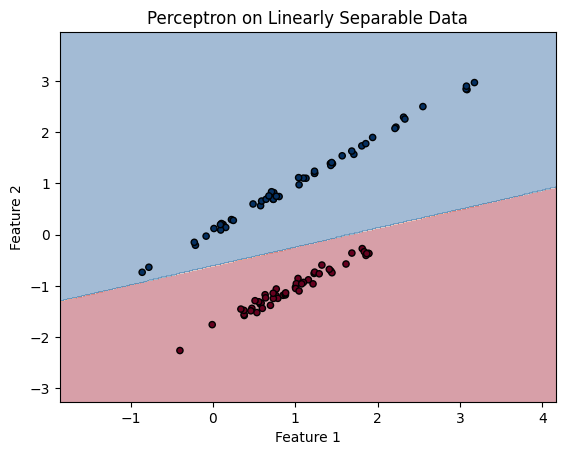


--- Perceptron on Non-Linearly Separable Data ---
Accuracy on non-linearly separable data: 0.49


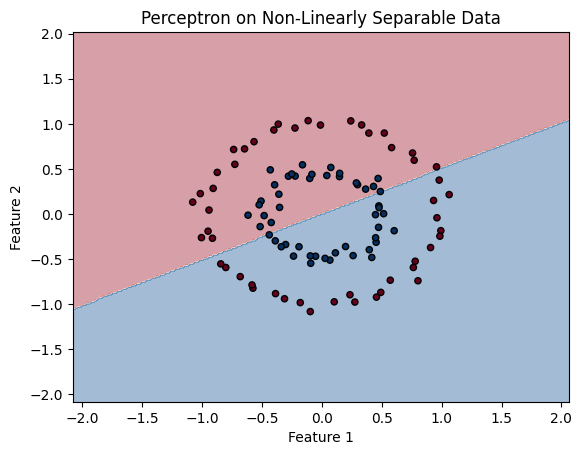


--- Multilayer Perceptron (MLP) ---
MLP Accuracy: 0.83


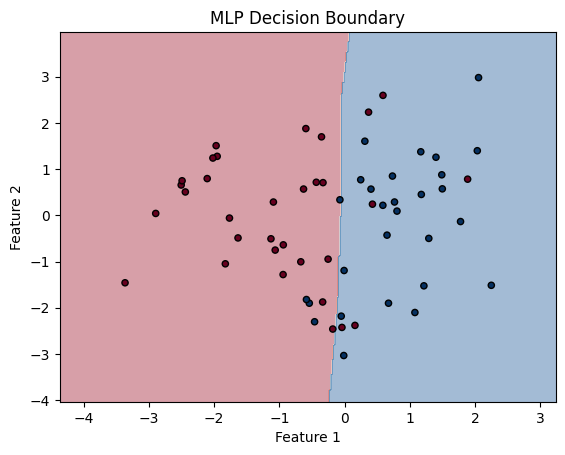

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Perceptron Implementation
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activate(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activate(linear_output)

                update = self.learning_rate * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activate(linear_output)

# Helper function to plot decision boundary
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdBu)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()


# --- Test on Linearly Separable Data ---
print("\n--- Perceptron on Linearly Separable Data ---")
X_linear, y_linear = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
y_linear = np.where(y_linear == 0, 0, 1) # Ensure binary 0 or 1

perceptron_linear = Perceptron(learning_rate=0.01, epochs=1000)
perceptron_linear.fit(X_linear, y_linear)
y_pred_linear = perceptron_linear.predict(X_linear)
print(f"Accuracy on linearly separable data: {accuracy_score(y_linear, y_pred_linear):.2f}")
plot_decision_boundary(X_linear, y_linear, perceptron_linear, "Perceptron on Linearly Separable Data")

# --- Test on Non-Linearly Separable Data (XOR-like) ---
print("\n--- Perceptron on Non-Linearly Separable Data ---")
X_nonlinear, y_nonlinear = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)
y_nonlinear = np.where(y_nonlinear == 0, 0, 1)

perceptron_nonlinear = Perceptron(learning_rate=0.01, epochs=1000)
perceptron_nonlinear.fit(X_nonlinear, y_nonlinear)
y_pred_nonlinear = perceptron_nonlinear.predict(X_nonlinear)
print(f"Accuracy on non-linearly separable data: {accuracy_score(y_nonlinear, y_pred_nonlinear):.2f}")
plot_decision_boundary(X_nonlinear, y_nonlinear, perceptron_nonlinear, "Perceptron on Non-Linearly Separable Data")


# --- Multilayer Perceptron (MLP) Implementation with scikit-learn ---
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

print("\n--- Multilayer Perceptron (MLP) ---")

# Generate a more complex dataset for MLP
X_mlp, y_mlp = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=2, random_state=42)

# Split data for MLP
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(X_mlp, y_mlp, test_size=0.3, random_state=42)

# Scale data for MLP
scaler_mlp = StandardScaler()
X_train_mlp_scaled = scaler_mlp.fit_transform(X_train_mlp)
X_test_mlp_scaled = scaler_mlp.transform(X_test_mlp)

# Train MLP Classifier
# One hidden layer with 10 neurons, 'relu' activation, 'adam' solver
mlp = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train_mlp_scaled, y_train_mlp)

# Evaluate MLP
y_pred_mlp = mlp.predict(X_test_mlp_scaled)
print(f"MLP Accuracy: {accuracy_score(y_test_mlp, y_pred_mlp):.2f}")

# Plot decision boundary for MLP
def plot_mlp_decision_boundary(X, y, model, scaler, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Scale the meshgrid points before prediction
    Z_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
    Z = model.predict(Z_scaled)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdBu)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_mlp_decision_boundary(X_test_mlp, y_test_mlp, mlp, scaler_mlp, "MLP Decision Boundary")

## 7. Forward Propagation and Backpropagation Algorithm
a)
Manually compute forward propagation for a small neural network (given weights and
inputs) and verify the output using code.
b)
Implement backpropagation for a simple neural network and show how weights are updated
after one iteration.

In [8]:
import numpy as np

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid function
def sigmoid_derivative(x):
    return x * (1 - x)

# --- Part a: Forward Propagation ---
print("--- Part a: Forward Propagation ---")

# Given inputs and weights for a simple network:
# Input layer (2 neurons) -> Hidden layer (2 neurons) -> Output layer (1 neuron)

# Inputs
X_fp = np.array([0.5, 0.1])

# Weights from input layer to hidden layer
w_ih_fp = np.array([
    [0.1, 0.4],  # Weights for hidden neuron 1 from input 1 and 2
    [0.8, 0.6]   # Weights for hidden neuron 2 from input 1 and 2
])

# Biases for hidden layer
b_h_fp = np.array([0.2, 0.3])

# Weights from hidden layer to output layer
w_ho_fp = np.array([
    [0.5], # Weight for output neuron from hidden neuron 1
    [0.9]  # Weight for output neuron from hidden neuron 2
])

# Bias for output layer
b_o_fp = np.array([0.7])

print(f"Inputs (X): {X_fp}")
print(f"Input-Hidden Weights (w_ih):\n{w_ih_fp}")
print(f"Hidden Biases (b_h): {b_h_fp}")
print(f"Hidden-Output Weights (w_ho):\n{w_ho_fp}")
print(f"Output Bias (b_o): {b_o_fp}\n")

# Manual Forward Propagation Calculation:

# 1. Calculate hidden layer input (z_h)
# z_h1 = X[0]*w_ih[0,0] + X[1]*w_ih[1,0] + b_h[0]
# z_h2 = X[0]*w_ih[0,1] + X[1]*w_ih[1,1] + b_h[1]

z_h_fp = np.dot(X_fp, w_ih_fp) + b_h_fp
print(f"Hidden layer inputs (z_h): {z_h_fp[0]:.4f}, {z_h_fp[1]:.4f}\n")

# 2. Apply activation function to hidden layer (a_h)
a_h_fp = sigmoid(z_h_fp)
print(f"Hidden layer outputs (a_h): {a_h_fp[0]:.4f}, {a_h_fp[1]:.4f}\n")

# 3. Calculate output layer input (z_o)
# z_o1 = a_h[0]*w_ho[0] + a_h[1]*w_ho[1] + b_o[0]
z_o_fp = np.dot(a_h_fp, w_ho_fp) + b_o_fp
print(f"Output layer input (z_o): {z_o_fp[0]:.4f}\n")

# 4. Apply activation function to output layer (a_o)
a_o_fp = sigmoid(z_o_fp)
print(f"Output layer output (a_o): {a_o_fp[0]:.4f}\n")


# --- Part b: Backpropagation ---
print("\n--- Part b: Backpropagation ---")

# Define the target output
y_target = np.array([0.7])
print(f"Target Output (y_target): {y_target}\n")

# Calculate error at output layer
output_error = y_target - a_o_fp
print(f"Output Error: {output_error[0]:.4f}\n")

# Calculate delta for output layer (d_output)
d_output = output_error * sigmoid_derivative(a_o_fp)
print(f"Delta Output: {d_output[0]:.4f}\n")

# Calculate error for hidden layer (based on d_output and w_ho)
hidden_error = d_output @ w_ho_fp.T
print(f"Hidden Error: {hidden_error[0]:.4f}, {hidden_error[1]:.4f}\n")

# Calculate delta for hidden layer (d_hidden)
d_hidden = hidden_error * sigmoid_derivative(a_h_fp)
print(f"Delta Hidden: {d_hidden[0]:.4f}, {d_hidden[1]:.4f}\n")

# Update weights and biases
learning_rate_bp = 0.5

# Update hidden-to-output weights and bias
dW_ho = a_h_fp.reshape(2,1) @ d_output
db_o = d_output

new_w_ho = w_ho_fp + learning_rate_bp * dW_ho
new_b_o = b_o_fp + learning_rate_bp * db_o

print(f"Updated Hidden-Output Weights (new_w_ho):\n{new_w_ho[0][0]:.4f}\n{new_w_ho[1][0]:.4f}\n")
print(f"Updated Output Bias (new_b_o): {new_b_o[0]:.4f}\n")

# Update input-to-hidden weights and biases
dW_ih = X_fp.reshape(2,1) @ d_hidden.reshape(1,2)
db_h = d_hidden

new_w_ih = w_ih_fp + learning_rate_bp * dW_ih
new_b_h = b_h_fp + learning_rate_bp * db_h

print(f"Updated Input-Hidden Weights (new_w_ih):\n{new_w_ih[0,0]:.4f}, {new_w_ih[0,1]:.4f}\n{new_w_ih[1,0]:.4f}, {new_w_ih[1,1]:.4f}\n")
print(f"Updated Hidden Biases (new_b_h): {new_b_h[0]:.4f}, {new_b_h[1]:.4f}")

--- Part a: Forward Propagation ---
Inputs (X): [0.5 0.1]
Input-Hidden Weights (w_ih):
[[0.1 0.4]
 [0.8 0.6]]
Hidden Biases (b_h): [0.2 0.3]
Hidden-Output Weights (w_ho):
[[0.5]
 [0.9]]
Output Bias (b_o): [0.7]

Hidden layer inputs (z_h): 0.3300, 0.5600

Hidden layer outputs (a_h): 0.5818, 0.6365

Output layer input (z_o): 1.5637

Output layer output (a_o): 0.8269


--- Part b: Backpropagation ---
Target Output (y_target): [0.7]

Output Error: -0.1269

Delta Output: -0.0182

Hidden Error: -0.0091, -0.0163

Delta Hidden: -0.0022, -0.0038

Updated Hidden-Output Weights (new_w_ho):
0.4947
0.8947

Updated Output Bias (new_b_o): 0.6909

Updated Input-Hidden Weights (new_w_ih):
0.0994, 0.3991
0.7999, 0.5998

Updated Hidden Biases (new_b_h): 0.1989, 0.2981


## 8. Gradient Descent and Stochastic Gradient Descent (SGD)
a)
Implement Gradient Descent to minimize a cost function and analyze the effect of learning
rate on convergence speed.
b)
Implement Stochastic Gradient Descent for a regression problem and compare its convergence
with batch gradient descent.

--- Part a: Gradient Descent and Learning Rate Effect ---
Learning Rate: 0.001, Final Cost: 1.0380
Learning Rate: 0.01, Final Cost: 0.9924
Learning Rate: 0.1, Final Cost: 0.9924


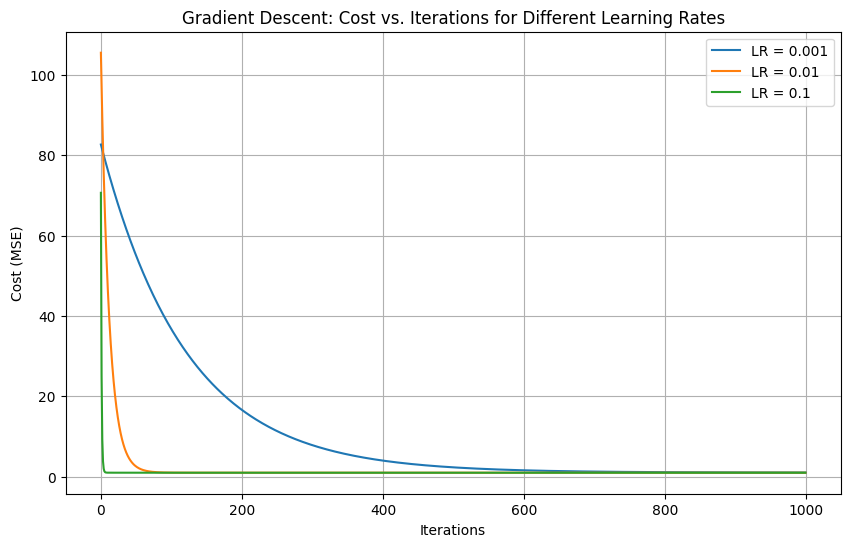


--- Part b: Stochastic Gradient Descent (SGD) vs Batch Gradient Descent ---


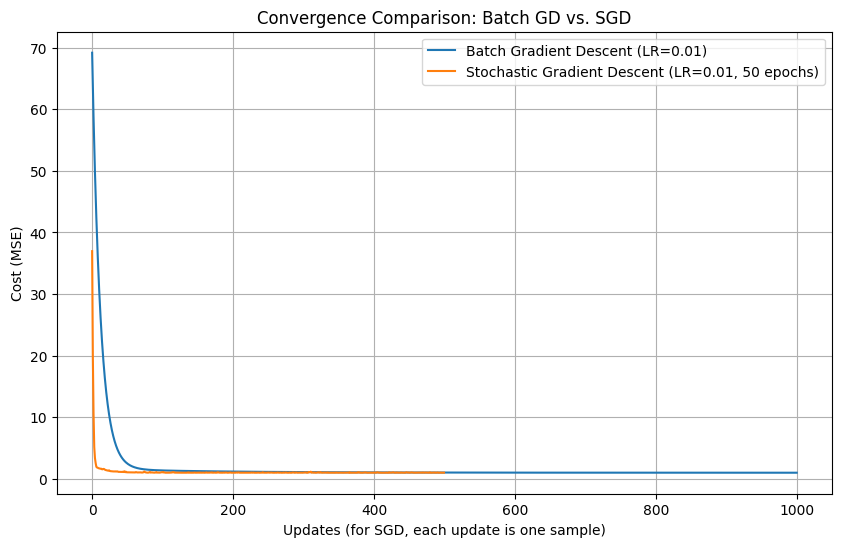

Batch GD Final Cost: 0.9935
SGD Final Cost: 1.0012


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Part a: Gradient Descent ---
print("--- Part a: Gradient Descent and Learning Rate Effect ---")

# Generate synthetic data for a simple linear regression problem
np.random.seed(0)
X_gd = 2 * np.random.rand(100, 1)
y_gd = 4 + 3 * X_gd + np.random.randn(100, 1)

# Add bias term to X
X_b_gd = np.c_[np.ones((100, 1)), X_gd]

# Cost function (Mean Squared Error)
def cost_function(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Gradient Descent function
def gradient_descent(X, y, learning_rate, n_iterations):
    m = len(X)
    theta = np.random.randn(X.shape[1], 1) # Initialize random theta
    cost_history = []

    for iteration in range(n_iterations):
        predictions = X @ theta
        errors = predictions - y
        gradients = 2/m * X.T @ errors
        theta = theta - learning_rate * gradients
        cost = cost_function(y, predictions)
        cost_history.append(cost)
    return theta, cost_history

# Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1]
n_iterations_gd = 1000

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    theta_final_gd, cost_hist_gd = gradient_descent(X_b_gd, y_gd, lr, n_iterations_gd)
    plt.plot(range(n_iterations_gd), cost_hist_gd, label=f'LR = {lr}')
    print(f"Learning Rate: {lr}, Final Cost: {cost_hist_gd[-1]:.4f}")

plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent: Cost vs. Iterations for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()


# --- Part b: Stochastic Gradient Descent (SGD) ---
print("\n--- Part b: Stochastic Gradient Descent (SGD) vs Batch Gradient Descent ---")

# SGD function
def stochastic_gradient_descent(X, y, learning_rate, n_epochs):
    m = len(X)
    theta = np.random.randn(X.shape[1], 1) # Initialize random theta
    cost_history_sgd = []

    for epoch in range(n_epochs):
        for i in range(m): # Iterate over each training instance
            random_index = np.random.randint(m)
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]

            predictions = xi @ theta
            errors = predictions - yi
            gradients = 2 * xi.T @ errors # Gradient for a single instance
            theta = theta - learning_rate * gradients

            # Calculate cost over the full dataset periodically to track convergence
            if i % 10 == 0: # Check every 10 samples for plotting smoothness
                cost = cost_function(y, X @ theta)
                cost_history_sgd.append(cost)
    return theta, cost_history_sgd


# Compare SGD with Batch GD
# Batch GD (from part a, using LR=0.01 for comparison)
theta_batch_gd, cost_hist_batch_gd = gradient_descent(X_b_gd, y_gd, 0.01, 1000)

# SGD
learning_rate_sgd = 0.01
n_epochs_sgd = 50

theta_sgd, cost_hist_sgd = stochastic_gradient_descent(X_b_gd, y_gd, learning_rate_sgd, n_epochs_sgd)

plt.figure(figsize=(10, 6))
plt.plot(cost_hist_batch_gd, label='Batch Gradient Descent (LR=0.01)')
plt.plot(cost_hist_sgd, label='Stochastic Gradient Descent (LR=0.01, 50 epochs)')
plt.xlabel('Updates (for SGD, each update is one sample)')
plt.ylabel('Cost (MSE)')
plt.title('Convergence Comparison: Batch GD vs. SGD')
plt.legend()
plt.grid(True)
plt.show()

print(f"Batch GD Final Cost: {cost_hist_batch_gd[-1]:.4f}")
print(f"SGD Final Cost: {cost_hist_sgd[-1]:.4f}")

## 9. Regularization
Implement L1 and L2 regularization for a linear regression model. Analyze their effect on
model coefficients and generalization performance.

--- Linear Regression (No Regularization) ---
MSE (OLS): 37.6677

--- Ridge Regression (L2 Regularization) ---
Alpha (L2): 0.01 , MSE: 37.6232
Alpha (L2): 1    , MSE: 34.8334
Alpha (L2): 100  , MSE: 31.9733

--- Lasso Regression (L1 Regularization) ---
Alpha (L1): 0.001, MSE: 37.5803
Alpha (L1): 0.1  , MSE: 32.5762
Alpha (L1): 1    , MSE: 32.2333


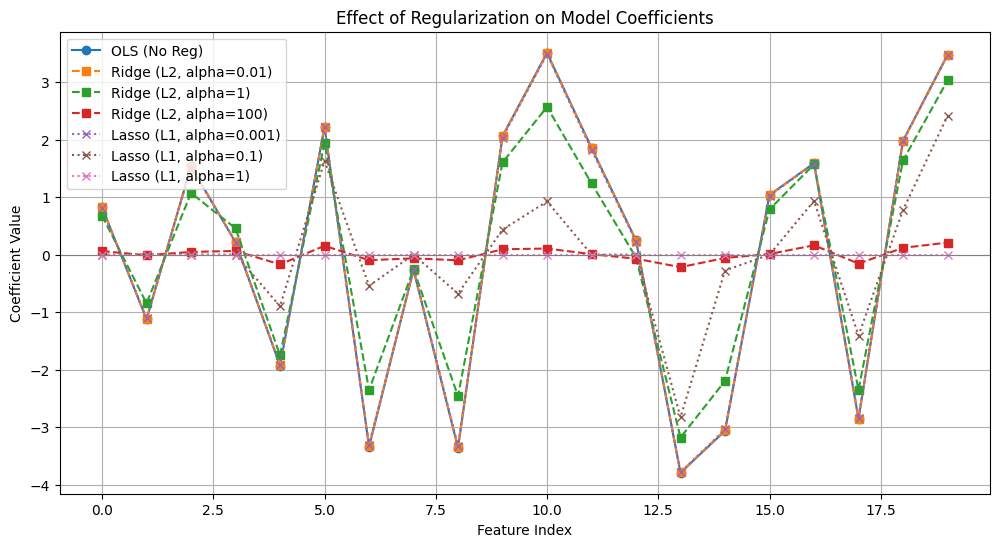

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate synthetic data with some noise and high dimensionality for potential overfitting
np.random.seed(42)
X_reg = np.random.rand(100, 20) # 100 samples, 20 features
y_reg = X_reg @ np.random.rand(20, 1) + 5 * np.random.randn(100, 1) # Linear relationship + noise

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Add bias term
X_train_b_reg = np.c_[np.ones((X_train_reg.shape[0], 1)), X_train_reg]
X_test_b_reg = np.c_[np.ones((X_test_reg.shape[0], 1)), X_test_reg]

# --- Linear Regression (No Regularization) ---
print("--- Linear Regression (No Regularization) ---")

def linear_regression_solve(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

theta_ols = linear_regression_solve(X_train_b_reg, y_train_reg)
y_pred_ols = X_test_b_reg @ theta_ols
mse_ols = mean_squared_error(y_test_reg, y_pred_ols)
print(f"MSE (OLS): {mse_ols:.4f}")

# --- Ridge Regression (L2 Regularization) ---
print("\n--- Ridge Regression (L2 Regularization) ---")

def ridge_regression_solve(X, y, alpha):
    identity_matrix = np.eye(X.shape[1])
    # Don't regularize the bias term (first element of theta)
    identity_matrix[0, 0] = 0
    return np.linalg.inv(X.T @ X + alpha * identity_matrix) @ X.T @ y

alphas_l2 = [0.01, 1, 100]
ridge_coefficients = []

for alpha in alphas_l2:
    theta_ridge = ridge_regression_solve(X_train_b_reg, y_train_reg, alpha)
    y_pred_ridge = X_test_b_reg @ theta_ridge
    mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
    print(f"Alpha (L2): {alpha:<5}, MSE: {mse_ridge:.4f}")
    ridge_coefficients.append(theta_ridge[1:]) # Exclude bias for plotting

# --- Lasso Regression (L1 Regularization) ---
# Custom implementation of Lasso is more complex due to non-differentiable L1 norm
# For simplicity and demonstration, we'll use sklearn's Lasso for actual coefficient computation
# but explain the concept.

print("\n--- Lasso Regression (L1 Regularization) ---")

from sklearn.linear_model import Lasso

alphas_l1 = [0.001, 0.1, 1]
lasso_coefficients = []

for alpha in alphas_l1:
    # Using sklearn's Lasso which handles regularization of coefficients excluding intercept by default
    lasso_model = Lasso(alpha=alpha, max_iter=2000, random_state=42)
    lasso_model.fit(X_train_reg, y_train_reg)
    y_pred_lasso = lasso_model.predict(X_test_reg).reshape(-1, 1)
    mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
    print(f"Alpha (L1): {alpha:<5}, MSE: {mse_lasso:.4f}")
    lasso_coefficients.append(lasso_model.coef_.reshape(-1,1))

# Plotting coefficients
plt.figure(figsize=(12, 6))
plt.plot(theta_ols[1:], 'o-', label='OLS (No Reg)')

for i, alpha in enumerate(alphas_l2):
    plt.plot(ridge_coefficients[i], 's--', label=f'Ridge (L2, alpha={alpha})')

for i, alpha in enumerate(alphas_l1):
    plt.plot(lasso_coefficients[i], 'x:', label=f'Lasso (L1, alpha={alpha})')

plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Effect of Regularization on Model Coefficients')
plt.legend()
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.8)
plt.show()

## 10. Principal Component Analysis (PCA)
Apply PCA for dimensionality reduction on a given dataset. Visualize the original and reduced
dimensionality data. Analyze the variance explained by each principal component.

--- Principal Component Analysis (PCA) ---
Original dataset shape: (150, 4)

Explained variance ratio for each component:
PC1: 0.7296
PC2: 0.2285
PC3: 0.0367
PC4: 0.0052
Total explained variance: 1.0000



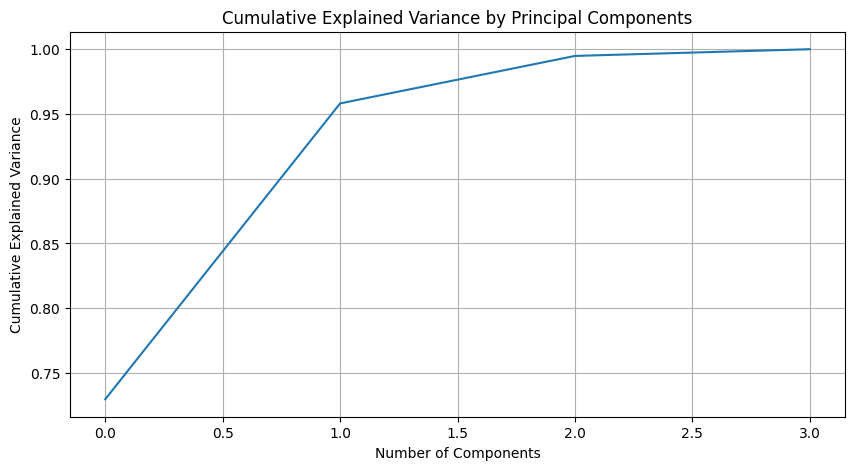

Reduced dataset shape (2 components): (150, 2)

Explained variance with 2 components: 0.9581



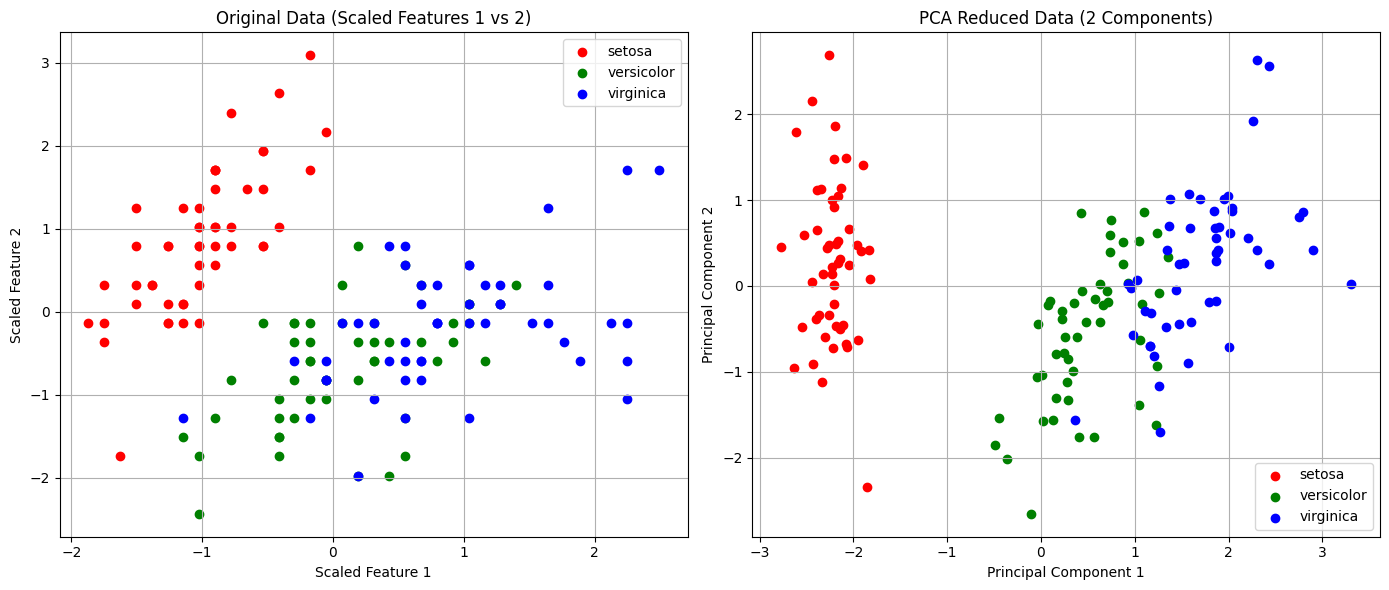

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Iris dataset
iris = load_iris()
X_pca = iris.data
y_pca = iris.target
target_names = iris.target_names

print("--- Principal Component Analysis (PCA) ---")
print(f"Original dataset shape: {X_pca.shape}\n")

# Standardize the data (important for PCA)
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca)

# --- Apply PCA ---
# Keep all components initially to analyze explained variance
pca = PCA(n_components=None)
X_pca_full = pca.fit_transform(X_scaled_pca)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio for each component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

print(f"Total explained variance: {np.sum(explained_variance_ratio):.4f}\n")

# Plot explained variance
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Components')
plt.grid(True)
plt.show()

# --- Reduce dimensionality to 2 components for visualization ---
pca_2d = PCA(n_components=2)
X_reduced_pca = pca_2d.fit_transform(X_scaled_pca)

print(f"Reduced dataset shape (2 components): {X_reduced_pca.shape}\n")
print(f"Explained variance with 2 components: {np.sum(pca_2d.explained_variance_ratio_):.4f}\n")

# --- Visualize Original Data (first two features) vs. PCA Reduced Data ---
plt.figure(figsize=(14, 6))

# Original Data (first two features)
plt.subplot(1, 2, 1)
for c, i, target_name in zip("rgb", [0, 1, 2], target_names):
    plt.scatter(X_scaled_pca[y_pca == i, 0],
                X_scaled_pca[y_pca == i, 1],
                c=c, label=target_name)
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.title('Original Data (Scaled Features 1 vs 2)')
plt.legend()
plt.grid(True)

# PCA Reduced Data (2 components)
plt.subplot(1, 2, 2)
for c, i, target_name in zip("rgb", [0, 1, 2], target_names):
    plt.scatter(X_reduced_pca[y_pca == i, 0],
                X_reduced_pca[y_pca == i, 1],
                c=c, label=target_name)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Reduced Data (2 Components)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()